# 获取斑马鱼的GO-BP

[GO](https://www.geneontology.org/)

> `GO_Ontology_BP`

Ontology >  biological_process

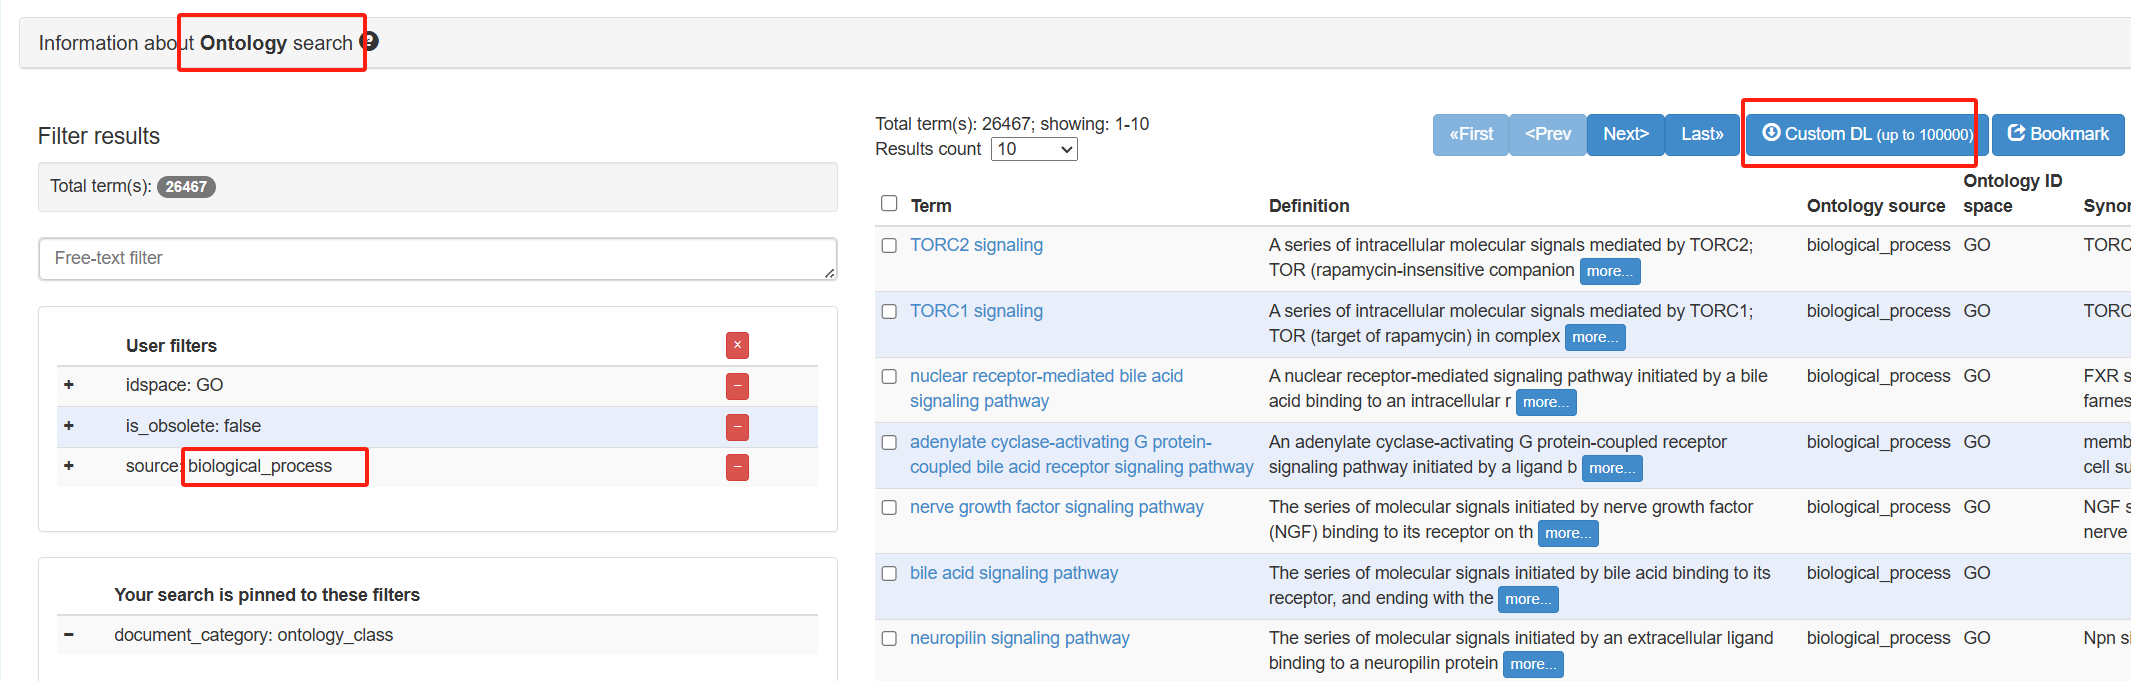

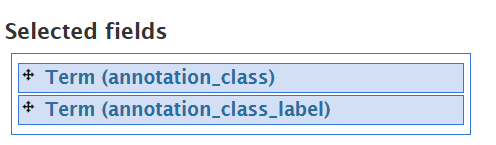


> `GO_GeneProduct_zebrafish`

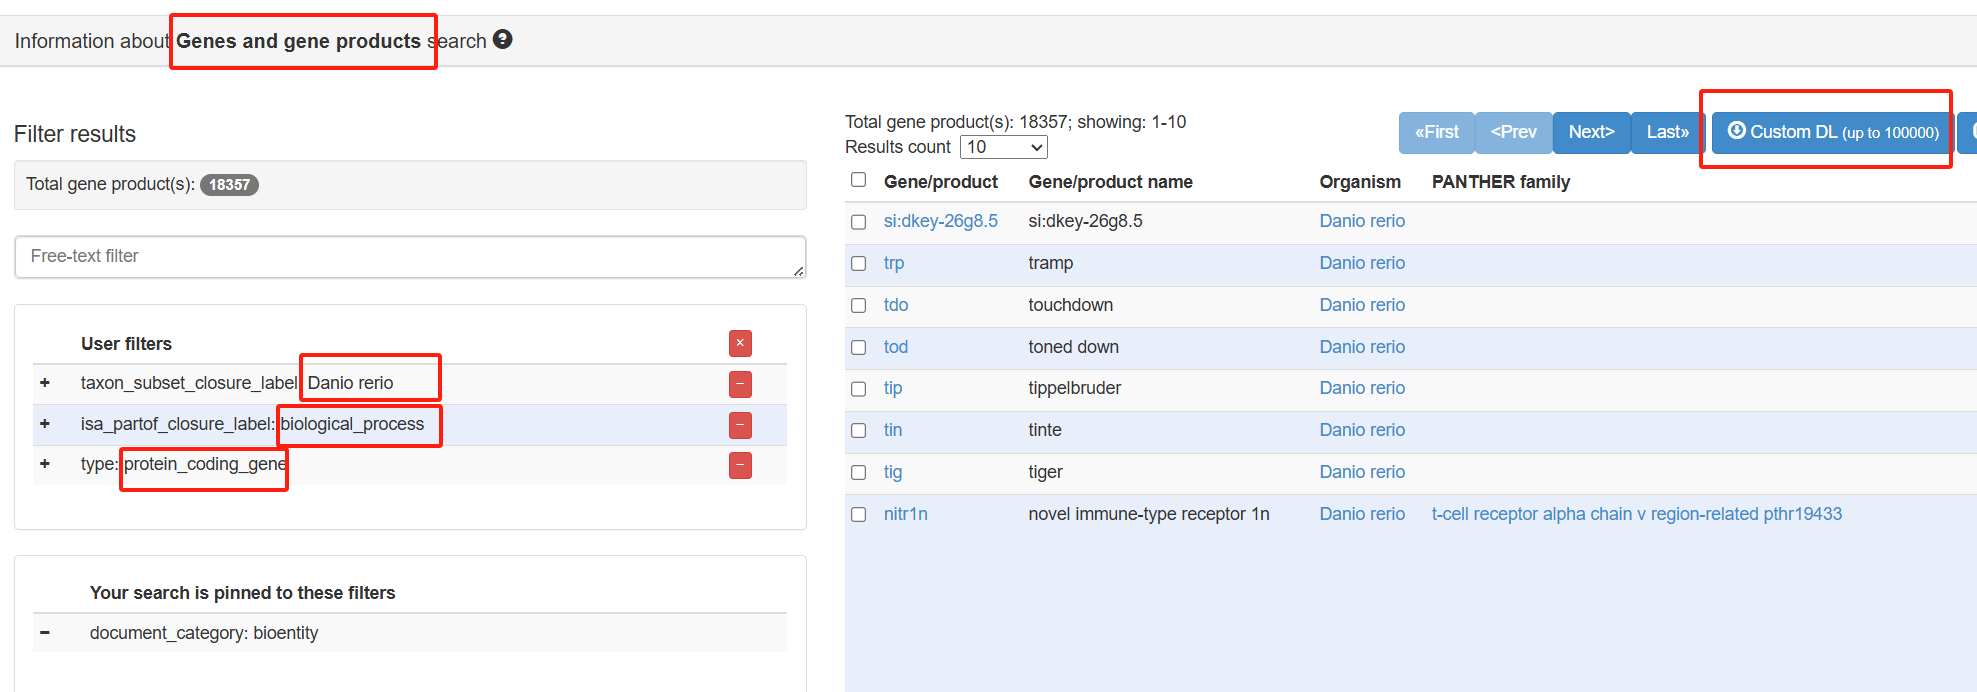


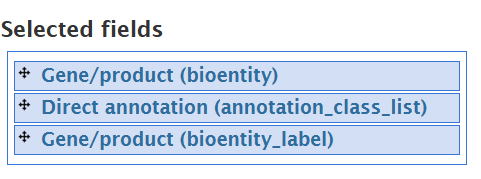

In [1]:
import sys
from pathlib import Path
from IPython.display import display

def sys_path_show():
    print(*sys.path, sep='\n')

def sys_path_append(p):
    p = Path(p)
    assert p.exists()
    p = str(p)
    None if p in sys.path else sys.path.append(p)

sys_path_append(Path("~/link").expanduser())

In [2]:
import utils as ut
from utils.general import *

In [3]:
df_bp = pd.read_csv('GO_Ontology_BP',sep='\t',header=None,names='term_id,term_label'.split(','))
df_gene = pd.read_csv('GO_GeneProduct_zebrafish',sep='\t',header=None,names='gene_id,term_ids,gene_name'.split(','))
ut.df.show(df_bp)
ut.df.show(df_gene)

,term_id,term_label
0,GO:0038203,TORC2 signaling
1,GO:0038202,TORC1 signaling


(26467, 2)

,gene_id,term_ids,gene_name
0,ZFIN:ZDB-GENE-121214-19,GO:0006508|GO:0008234|GO:0008233|GO:0016787,si:dkey-26g8.5
1,ZFIN:ZDB-GENE-070117-2436,GO:0001889,trp


(18357, 3)

In [4]:

data = {}

# display(df_gene.head(10))
# for i,row in df_gene.head(10).iterrows():
#     for term_id in row['term_ids'].split('|'):
#         data.setdefault(term_id,[]).append(row['gene_name'])

for i,row in df_gene.iterrows():
    print('\r[process][{}/{}]'.format(i+1,df_gene.shape[0]).ljust(15,'.'),end='')
    for term_id in row['term_ids'].split('|'):
        data.setdefault(term_id,[]).append(row['gene_name'])
print()

for k,v in data.items():
    data[k] = '\t'.join(np.unique(v))

[process][18357/18357]


In [5]:
data = pd.DataFrame({
    'term_id':data.keys(),
    'genes':data.values()
}).merge(df_bp,on='term_id').loc[:,'term_label,term_id,genes'.split(',')]
ut.df.show(data)

,term_label,term_id,genes
0,proteolysis,GO:0006508,ace\tace2\tactmap\tadam10a\tadam10b\tadam11\ta...
1,liver development,GO:0001889,a2ml\tacvr1l\taldh1a2\taldh8a1\tangptl3\tapc\t...


(5875, 3)

In [11]:
data.to_csv('TOSICA/TOSICA/resources/GO_BP_zebrafish.gmt',sep='\t',header=False,index=False)

In [ ]:
Path('TOSICA/TOSICA/resources/GO_bp.gmt').read_text().split('\n')[0]